In [ ]:
import yfinance as yf

# Fetch historical Bitcoin data
symbol = 'BTC-USD'  # Bitcoin to USD pair
btc_data = yf.download(symbol, start="2018-01-01", end="2024-11-01", interval='1d')

# Reset index and preview data
btc_data.reset_index(inplace=True)
print(btc_data.head())

[*********************100%***********************]  1 of 1 completed

Price        Date     Adj Close         Close          High           Low  \
Ticker                  BTC-USD       BTC-USD       BTC-USD       BTC-USD   
0      2018-01-01  13657.200195  13657.200195  14112.200195  13154.700195   
1      2018-01-02  14982.099609  14982.099609  15444.599609  13163.599609   
2      2018-01-03  15201.000000  15201.000000  15572.799805  14844.500000   
3      2018-01-04  15599.200195  15599.200195  15739.700195  14522.200195   
4      2018-01-05  17429.500000  17429.500000  17705.199219  15202.799805   

Price           Open       Volume  
Ticker       BTC-USD      BTC-USD  
0       14112.200195  10291200000  
1       13625.000000  16846600192  
2       14978.200195  16871900160  
3       15270.700195  21783199744  
4       15477.200195  23840899072  


In [ ]:
# Save the dataframe
btc_data.to_csv('btc_data.csv', index=False)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [ ]:
# Load Data
btc_data = pd.read_csv("btc_data.csv")
btc_data['Date'] = pd.to_datetime(btc_data['Date'])
btc_data.set_index('Date', inplace=True)

# Focus on closing prices, skipping the first row if it contains non-numeric data
data = btc_data[['Close']].values[1:]

In [ ]:
#  Normalize Data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

In [ ]:
# Create Sliding Window Dataset
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i + time_step, 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60  # Use the past 60 days to predict the next day
X, y = create_dataset(data_scaled, time_step)

# Reshape X for LSTM input
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
#  Split Data into Training and Testing Sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
#  Build LSTM Model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    tf.keras.layers.LSTM(50, return_sequences=False),
    tf.keras.layers.Dense(25),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
import numpy as np
import tensorflow as tf
import random

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Enable deterministic behavior in TensorFlow
tf.config.experimental.enable_op_determinism()

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Predict and forecast
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)


Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.0186 - val_loss: 0.0020
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 9.3899e-04 - val_loss: 0.0015
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 8.4602e-04 - val_loss: 0.0014
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 7.5891e-04 - val_loss: 0.0013
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 6.7868e-04 - val_loss: 0.0011
Epoch 9/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 6.0597e-04 - val_loss: 9.9176e-04
Epoch 10/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 5.4288e-04 - val_loss: 8.9056e-04
Epoch 11/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 4.9265e-04 - val_loss: 8.2186e-04
Epoch 12/50
61/61 ━━━━━

In [ ]:
# Inverse transform predictions and actual values
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [ ]:
# Calculate MAE
mae = mean_absolute_error(y_test_actual, test_predict)
print(f"Mean Absolute Error (MAE): {mae}")

Mean Absolute Error (MAE): 1604.6461441790452


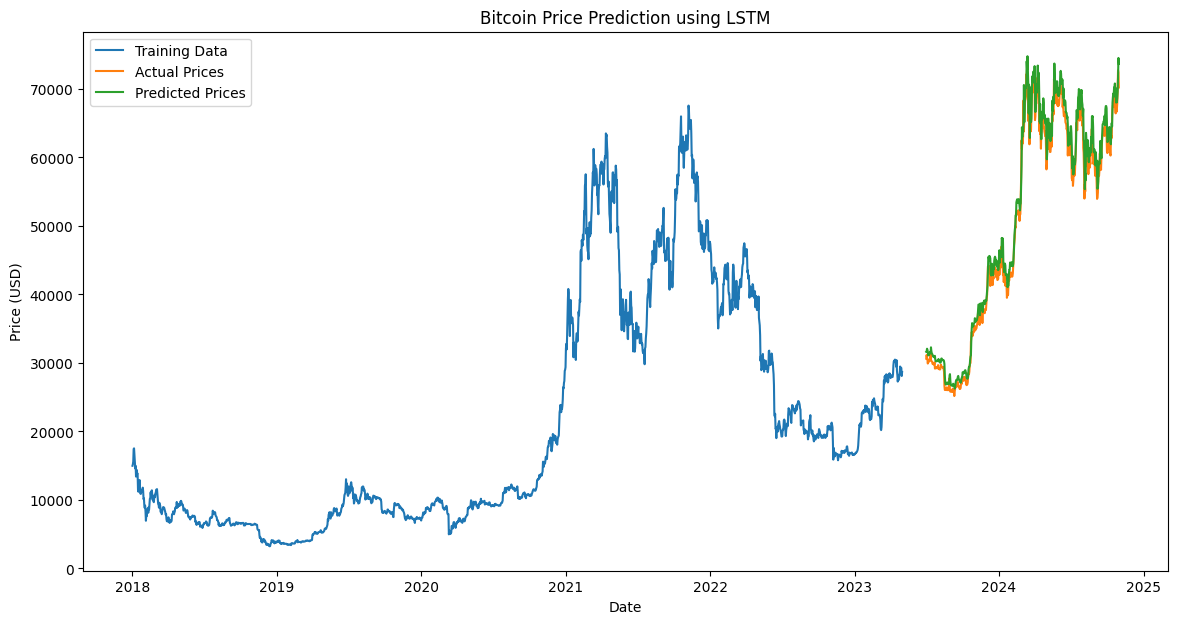

In [ ]:
#  Plot Predictions vs Actual Data
plt.figure(figsize=(14, 7))
plt.plot(btc_data.index[:train_size], scaler.inverse_transform(data_scaled[:train_size]), label="Training Data")


plt.plot(btc_data.index[train_size + time_step:train_size + time_step + len(y_test_actual)], y_test_actual, label="Actual Prices")
plt.plot(btc_data.index[train_size + time_step:train_size + time_step + len(test_predict)], test_predict, label="Predicted Prices")

plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.title("Bitcoin Price Prediction using LSTM")
plt.show()

In [ ]:
#  Forecast Future Prices
# Use the last 60 days of data for prediction
last_60_days = data_scaled[-time_step:]
X_future = last_60_days.reshape(1, time_step, 1)

In [ ]:
# Predict prices for the next 60 days
future_predictions = []
for _ in range(60):
    next_price = model.predict(X_future)
    future_predictions.append(next_price[0, 0])
    X_future = np.append(X_future[:, 1:, :], next_price.reshape(1, 1, 1), axis=1) #The problem was solved by reshaping the next_price

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━

In [ ]:
# Inverse transform predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

In [ ]:
# Generate dates for the forecast
forecast_dates = pd.date_range(start=btc_data.index[-1], periods=61, freq='D')[1:]
forecast_df = pd.DataFrame({"Date": forecast_dates, "Predicted Price": future_predictions.flatten()})

In [ ]:
# Save and display the forecast
forecast_df.to_csv("future_predictions.csv", index=False)
print(forecast_df.head())

        Date  Predicted Price
0 2024-11-01     71370.796875
1 2024-11-02     73151.804688
2 2024-11-03     75011.117188
3 2024-11-04     76821.554688
4 2024-11-05     78505.289062


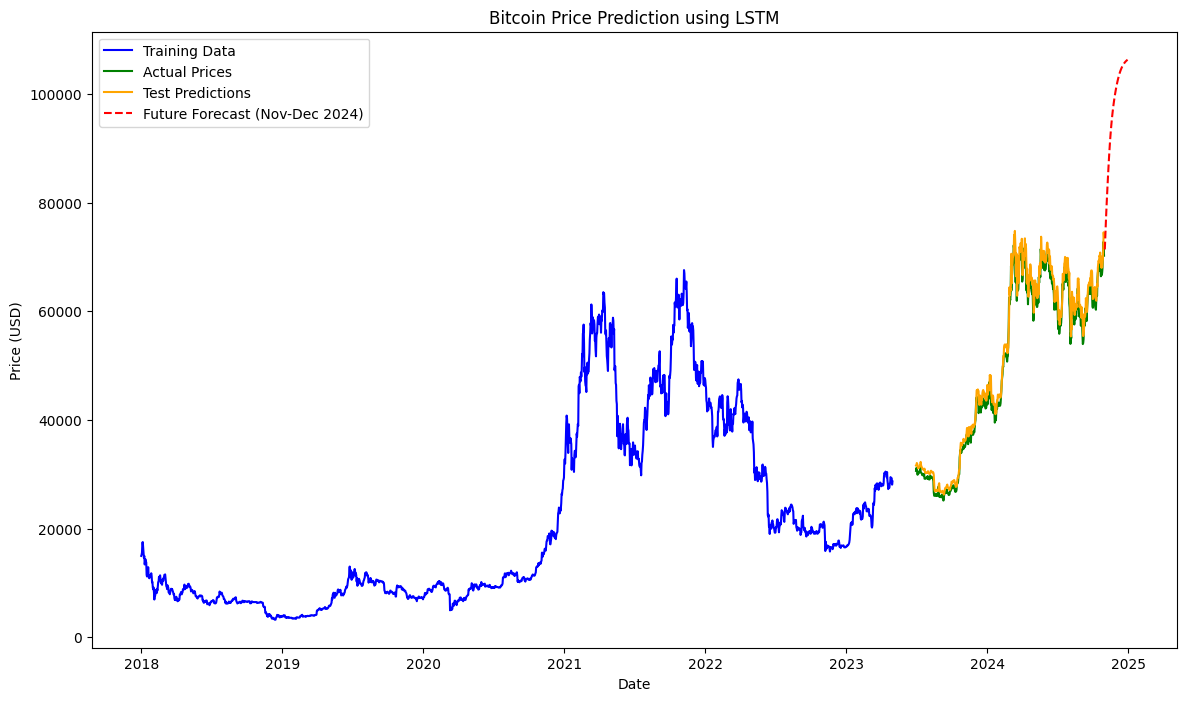

In [ ]:
import matplotlib.pyplot as plt

# 1. Plot Actual Prices, Predictions, and Future Forecast
plt.figure(figsize=(14, 8))

# Plot the actual prices
plt.plot(btc_data.index[:train_size], scaler.inverse_transform(data_scaled[:train_size]), label="Training Data", color="blue")


plt.plot(btc_data.index[train_size + time_step:train_size + time_step + y_test_actual.shape[0]],
         y_test_actual, label="Actual Prices", color="green")

# Similarly, adjust the x-axis for predicted prices
plt.plot(btc_data.index[train_size + time_step:train_size + time_step + test_predict.shape[0]],
         test_predict, label="Test Predictions", color="orange")

# Plot the future forecast
forecast_start_index = len(btc_data)
# Re-define forecast_dates_adjusted here:
forecast_dates_adjusted = pd.date_range(start=btc_data.index[-1], periods=len(future_predictions) + 1, freq='D')[1:]
plt.plot(forecast_dates_adjusted, future_predictions.flatten(),
         label="Future Forecast (Nov-Dec 2024)", color="red", linestyle="dashed")

plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.title("Bitcoin Price Prediction using LSTM")
plt.show()

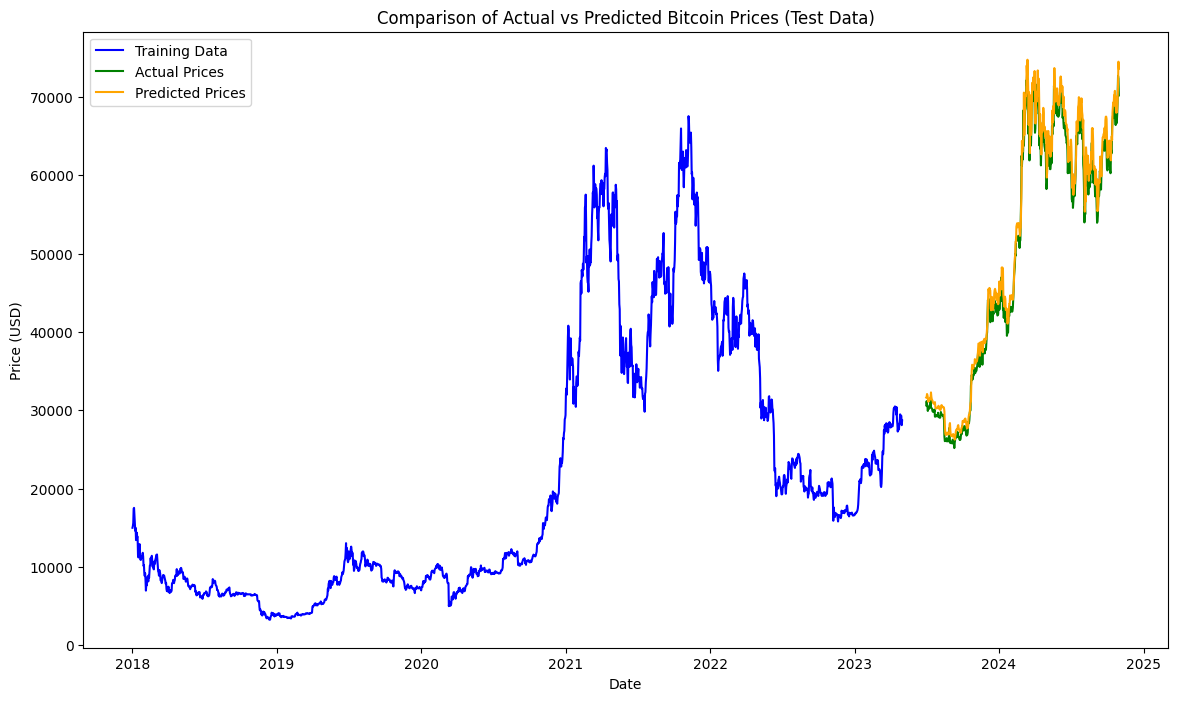

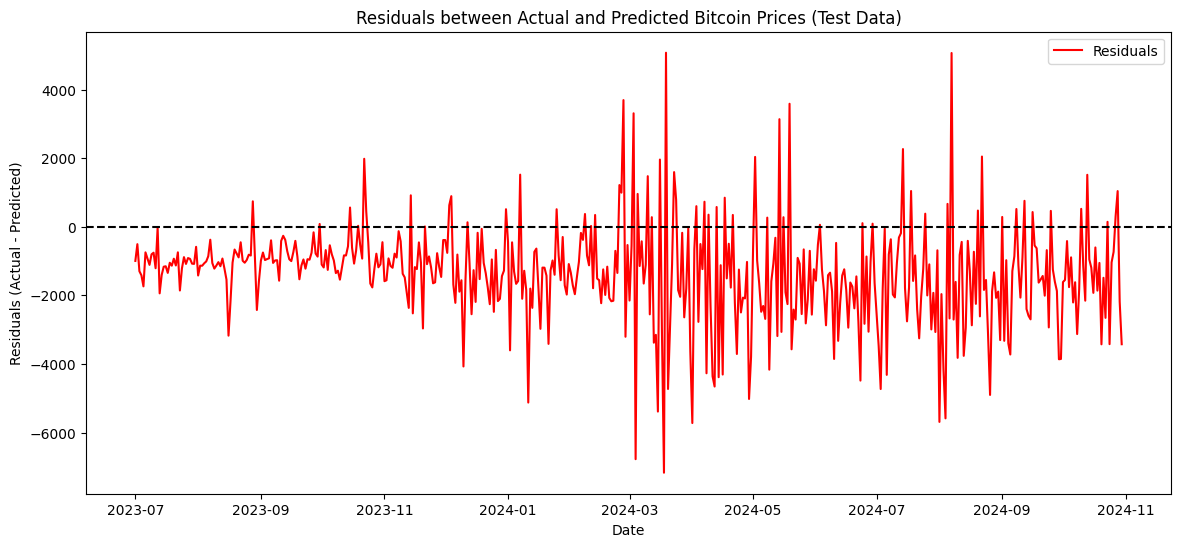

In [ ]:
#  Compare Predictions with Actual Values (Test Data)
plt.figure(figsize=(14, 8))

# Plot the actual prices
plt.plot(btc_data.index[:train_size], scaler.inverse_transform(data_scaled[:train_size]), label="Training Data", color="blue")

# Plot the actual test data (y_test_actual) vs the predicted data (test_predict)
plt.plot(btc_data.index[train_size + time_step:train_size + time_step + y_test_actual.shape[0]],
         y_test_actual, label="Actual Prices", color="green")

plt.plot(btc_data.index[train_size + time_step:train_size + time_step + test_predict.shape[0]],
         test_predict, label="Predicted Prices", color="orange")

# Add labels and title
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.title("Comparison of Actual vs Predicted Bitcoin Prices (Test Data)")

# Show the plot
plt.show()

#  Calculate the difference (residuals) between actual and predicted prices
residuals = y_test_actual.flatten() - test_predict.flatten()

#  Plot the residuals
plt.figure(figsize=(14, 6))
plt.plot(btc_data.index[train_size + time_step:train_size + time_step + len(residuals)], residuals, label="Residuals", color="red")
plt.axhline(y=0, color='black', linestyle='--')  # Line at y=0 for better visualization of the residuals
plt.xlabel("Date")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.title("Residuals between Actual and Predicted Bitcoin Prices (Test Data)")
plt.show()

[*********************100%***********************]  1 of 1 completed


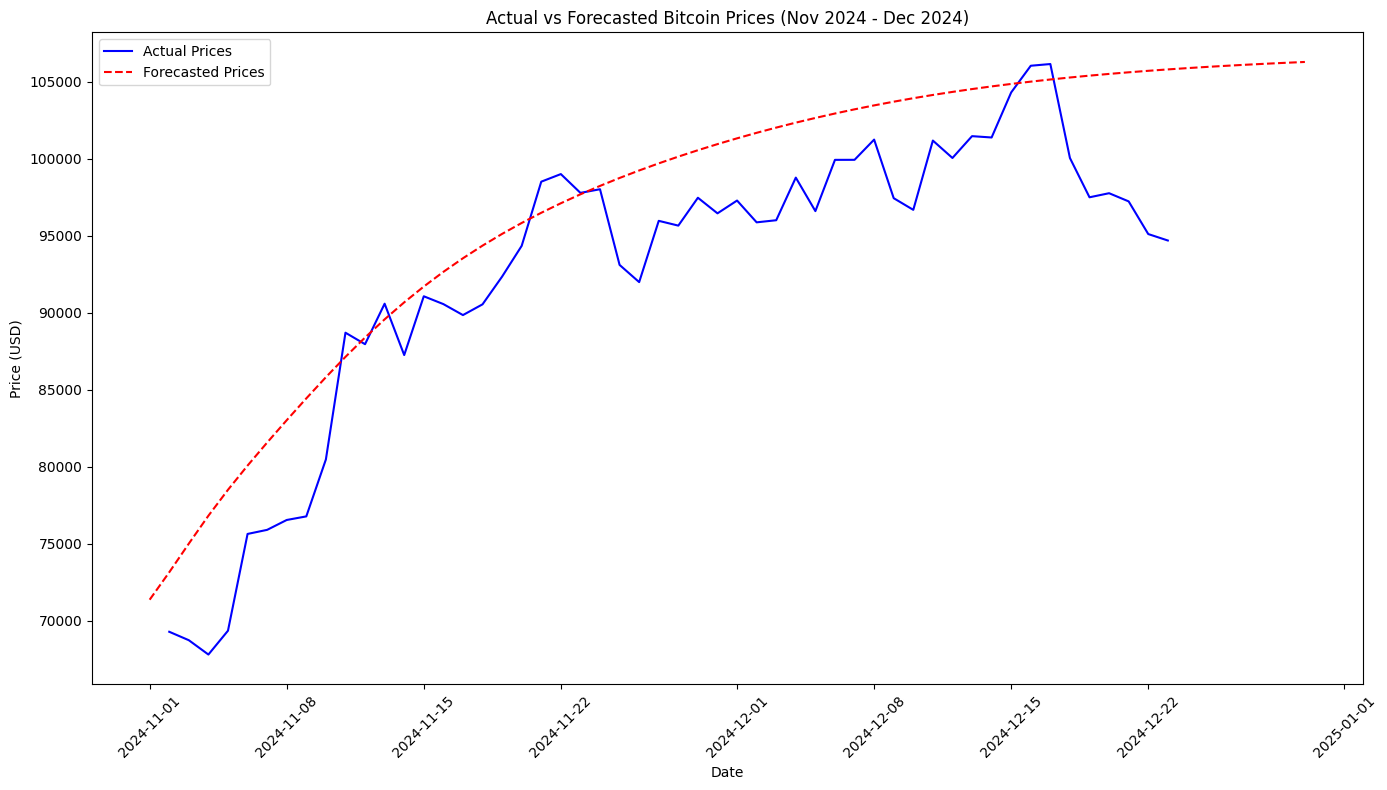

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# Download Bitcoin data for the period 2024-11-02 to 2024-12-24
symbol = 'BTC-USD'
btc_data_actual = yf.download(symbol, start="2024-11-02", end="2024-12-24", interval='1d')


forecast_df = pd.read_csv("future_predictions.csv")
# Reset index to create a 'Date' column
btc_data_actual = btc_data_actual.reset_index()

# Ensure the 'Date' column is in datetime format
btc_data_actual['Date'] = pd.to_datetime(btc_data_actual['Date'])
#Fixed: Changed btc_data._actual to btc_data_actual
btc_data_actual.set_index('Date', inplace=True)
forecast_df['Date'] = pd.to_datetime(forecast_df['Date'])

# Plot the actual vs forecasted data for the period 2024-11-02 to 2024-12-24
plt.figure(figsize=(14, 8))

# Plot the actual Bitcoin prices
plt.plot(btc_data_actual.index, btc_data_actual['Close'], label="Actual Prices", color="blue")


# Plot the forecasted Bitcoin prices
plt.plot(forecast_df['Date'], forecast_df['Predicted Price'], label="Forecasted Prices", color="red", linestyle="dashed")


plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.title("Actual vs Forecasted Bitcoin Prices (Nov 2024 - Dec 2024)")
plt.legend()


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#
actual_prices = btc_data_actual['Close'][-len(forecast_df):].values  # Get the actual prices for the forecasted period
forecasted_prices = forecast_df['Predicted Price'].values  # Get the forecasted prices from the model

# Slice forecasted prices to match the length of actual prices
forecasted_prices = forecasted_prices[:len(actual_prices)]

# Now actual_prices and forecasted_prices should have the same length
if len(actual_prices) != len(forecasted_prices):
    raise ValueError("Actual prices and forecasted prices have different lengths")

# 2. Calculate MAE (Mean Absolute Error)
mae = mean_absolute_error(actual_prices, forecasted_prices)

# 3. Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(actual_prices, forecasted_prices))

# 4. Calculate MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((actual_prices - forecasted_prices) / actual_prices)) * 100

# Print the accuracy metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")


Mean Absolute Error (MAE): 3928.7714423076923
Root Mean Squared Error (RMSE): 4662.99408316862
Mean Absolute Percentage Error (MAPE): 12.797056882908912%
